In [1]:
## Import Modules
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

## Plate Dimensions
a=10
b=10
## Mesh Grid
nx=a
ny=b
x=np.linspace(0,a,nx)
y=np.linspace(0,b,ny)
X,Y = np.meshgrid(x,y)

In [2]:
## Initial Condition
T1=150
T2=80
T3=150
T4=60
T_def=90
T_initial=np.zeros((nx,ny))
T_initial.fill(T_def)
T_initial[-1,:]=T2
T_initial[0,:]=T4
T_initial[:,0]=T1
T_initial[:,-1]=T3
## initialize lists
T_all=[]
T_current=T_initial.copy()
nit=50  ## no of iterations
print (T_initial)

[[150.  60.  60.  60.  60.  60.  60.  60.  60. 150.]
 [150.  90.  90.  90.  90.  90.  90.  90.  90. 150.]
 [150.  90.  90.  90.  90.  90.  90.  90.  90. 150.]
 [150.  90.  90.  90.  90.  90.  90.  90.  90. 150.]
 [150.  90.  90.  90.  90.  90.  90.  90.  90. 150.]
 [150.  90.  90.  90.  90.  90.  90.  90.  90. 150.]
 [150.  90.  90.  90.  90.  90.  90.  90.  90. 150.]
 [150.  90.  90.  90.  90.  90.  90.  90.  90. 150.]
 [150.  90.  90.  90.  90.  90.  90.  90.  90. 150.]
 [150.  80.  80.  80.  80.  80.  80.  80.  80. 150.]]


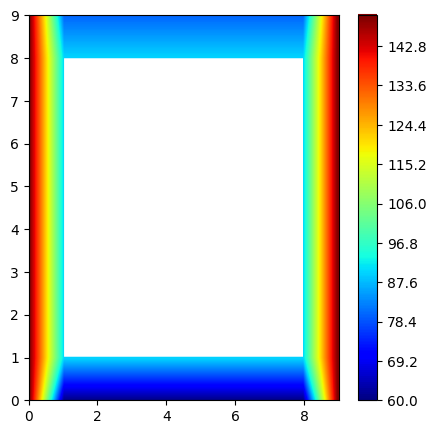

In [3]:
## Plot Initialcondition
fig1=plt.figure(figsize=(5,5))
ax1=fig1.add_subplot()
contour1=plt.contour(T_initial,500,cmap="jet",)
cbar=plt.colorbar(contour1,ax=ax1)
plt.show()

In [4]:
## Solve Central difference method for steady state condition
for t in range(0,nit):
    for i in range(1,nx-1):
        for j in range(1,ny-1):
            tem=(T_current[i,j+1] + T_current[i,j-1] +T_current[i+1,j]+T_current[i-1,j])/4
            T_current[i][j]=tem

    T_all.append(T_current.copy())

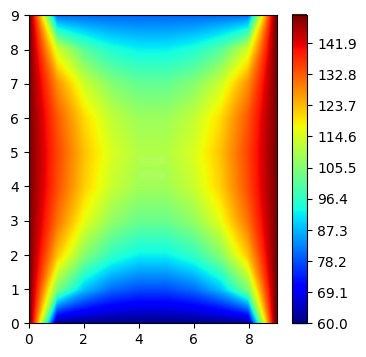

<Figure size 640x480 with 0 Axes>

In [5]:
##Plot final state
fig2=plt.figure(figsize=(4,4))
ax2=fig2.add_subplot()
contour2=plt.contour(T_all[-1],900,cmap="jet")
cbar=plt.colorbar(contour2)
plt.show()
plt.savefig("Final_State_Temperature_Distribution.png")

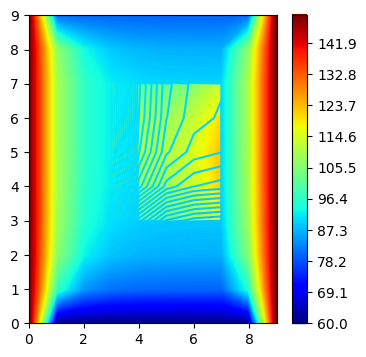

In [6]:
## Animate the Temperature Distribution
fig3=plt.figure(figsize=(4,4))
contour3=plt.contour(T_all[-1],900,cmap="jet")
cbar=plt.colorbar(contour3)

def animate(i):
    plt.contour(T_all[i],900,cmap="jet")

anim=animation.FuncAnimation(fig3,animate,frames=nit)
writer=animation.PillowWriter(fps=(10))
anim.save("Temperature_distribution.gif", writer=writer)